In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

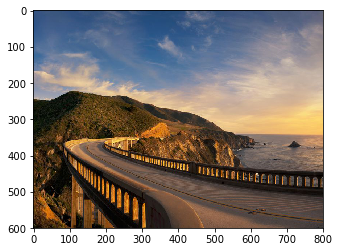

In [2]:
img_road = cv2.imread('DATA/road_image.jpg')
rgb_road = cv2.cvtColor(img_road, cv2.COLOR_BGR2RGB)

img_road_copy = np.copy(img_road)

plt.imshow(rgb_road)

In [3]:
img_road.shape

(600, 800, 3)

In [4]:
img_marker = np.zeros(img_road.shape[:2], dtype=np.int32)
img_segments = np.zeros(img_road.shape, dtype=np.uint8)

print(img_marker.shape)
print(img_segments.shape)

(600, 800)
(600, 800, 3)


In [5]:
# See matplotlib 'colormaps' from web
from matplotlib import cm

In [6]:
cm.tab10(0)

(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0)

In [7]:
cm.tab10(0)[:3]

(0.12156862745098039, 0.4666666666666667, 0.7058823529411765)

In [8]:
def create_rgb(i):
    return tuple(np.array(cm.tab10(i)[:3])*255)

In [9]:
colors = []

for i in range(10):                # 10 colors are present in tab10
    colors.append(create_rgb(i))
    
colors

[(31.0, 119.0, 180.0),
 (255.0, 127.0, 14.0),
 (44.0, 160.0, 44.0),
 (214.0, 39.0, 40.0),
 (148.0, 103.0, 189.0),
 (140.0, 86.0, 75.0),
 (227.0, 119.0, 194.0),
 (127.0, 127.0, 127.0),
 (188.0, 189.0, 34.0),
 (23.0, 190.0, 207.0)]

In [10]:
# Default settings
n_markers = 10
current_marker = 1
markers_updated = False    # Markers Updated by Watershed

In [11]:
def mouse_callback(event, x, y, flags, params):
    global markers_updated
    
    if event == cv2.EVENT_LBUTTONDOWN:
        
        # MARKERS PASSED TO THE WATERSHED ALGORITHM
        cv2.circle(img_marker, (x,y), 10, (current_marker), -1)
        
        # DISPLAY ON ROAD IMAGE
        cv2.circle(img_road_copy, (x, y), 10, colors[current_marker], -1)
        
        markers_updated = True

In [14]:
cv2.namedWindow('Road Image')
cv2.setMouseCallback('Road Image', mouse_callback)

while True:
    cv2.imshow('Watershed Segments', img_segments)
    cv2.imshow('Road Image', img_road_copy)
    
    k = cv2.waitKey(1) 
    
    if k == ord('q'):
       break
    
    # Clearing All Images
    elif k == ord('c'):
        img_road_copy = img_road.copy()
        img_marker = np.zeros(img_road.shape[:2], dtype=np.int32)
        img_segments = np.zeros(img_road.shape, dtype=np.uint8)
        
    # Update Color Choice
    elif k>0 and chr(k).isdigit():
        current_marker = int(chr(k))
        
    # Update the Markings
    if markers_updated:
        img_marker_copy = img_marker.copy()
        cv2.watershed(img_road, img_marker_copy)
        
        img_segments = np.zeros(img_road.shape, dtype=np.uint8)
        
        # Coloring the Segments
        for color_ind in range(n_markers):
            img_segments[img_marker_copy==(color_ind)] = colors[color_ind]
        
    
cv2.destroyAllWindows()